In [ ]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
# Загрузка данных
data = pd.read_csv(r'C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\data\raw\life_expectancy_data.csv')


In [10]:
# 1. Обзор данных
print("Первые строки данных:")
print(data.head())
print("\nИнформация о данных:")
data.info()
print("\nСтатистическое описание данных:")
print(data.describe())


Первые строки данных:
       Country  Year      Status  Life expectancy   Adult Mortality  \
0  Afghanistan  2015  Developing              65.0            263.0   
1  Afghanistan  2014  Developing              59.9            271.0   
2  Afghanistan  2013  Developing              59.9            268.0   
3  Afghanistan  2012  Developing              59.5            272.0   
4  Afghanistan  2011  Developing              59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles  ...  \
0             62     0.01               71.279624         65.0     1154  ...   
1             64     0.01               73.523582         62.0      492  ...   
2             66     0.01               73.219243         64.0      430  ...   
3             69     0.01               78.184215         67.0     2787  ...   
4             71     0.01                7.097109         68.0     3013  ...   

   Polio  Total expenditure  Diphtheria   HIV/AIDS         GDP  Popula

In [11]:
# 2. Проверка пропущенных значений
print("\nКоличество пропущенных значений по столбцам:")
print(data.isnull().sum())

# Обработка пропусков
for col in data.columns:
    if data[col].isnull().sum() > 0:
        if data[col].dtype == 'object':
            # Заполнение пропусков модой для категориальных переменных
            data[col] = data[col].fillna(data[col].mode()[0])
        else:
            # Заполнение пропусков медианой для числовых переменных
            data[col] = data[col].fillna(data[col].median())


# Проверяем, что пропущенные значения устранены
print("\nПропущенные значения после обработки:")
print(data.isnull().sum())



Количество пропущенных значений по столбцам:
Country                              0
Year                                 0
Status                               0
Life expectancy                      8
Adult Mortality                      8
infant deaths                        0
Alcohol                            185
percentage expenditure               0
Hepatitis B                        525
Measles                              0
BMI                                 33
under-five deaths                    0
Polio                               18
Total expenditure                  215
Diphtheria                          18
 HIV/AIDS                            0
GDP                                415
Population                         604
thinness 10-19 years                33
thinness 5-9 years                  33
Income composition of resources    155
Schooling                          151
dtype: int64

Пропущенные значения после обработки:
Country                            0
Year   

In [12]:
# 3. Поиск дубликатов
print("\nКоличество дублированных строк:", data.duplicated().sum())
# Удаление дубликатов
data = data.drop_duplicates()



Количество дублированных строк: 0


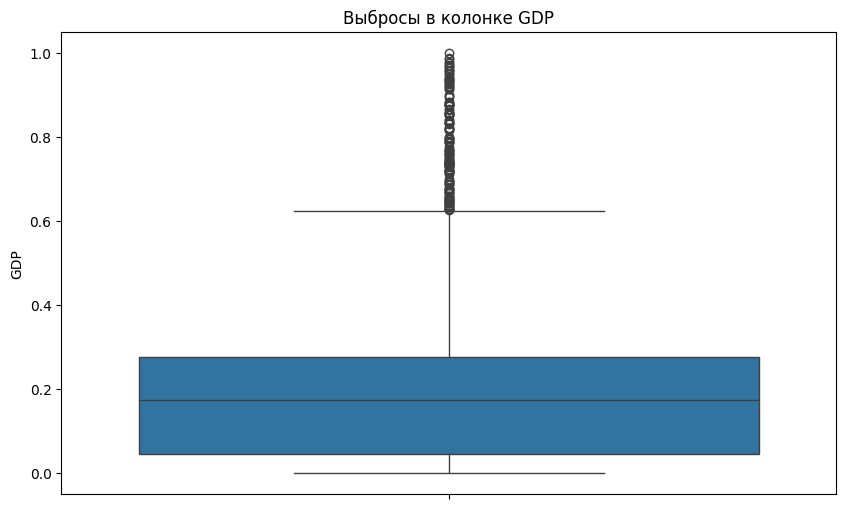

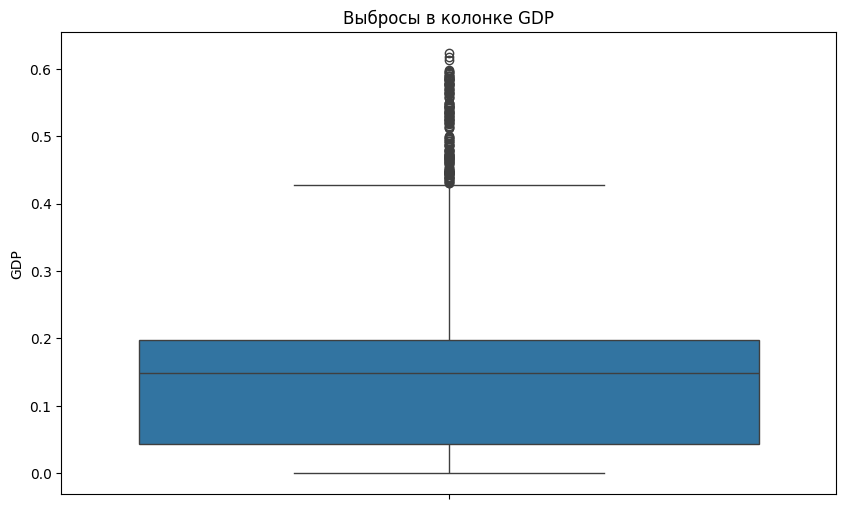

In [18]:
# 4. Поиск выбросов
# Пример для столбца 'GDP'
plt.figure(figsize=(10, 6))
sns.boxplot(data['GDP'])
plt.title('Выбросы в колонке GDP')
plt.show()

# Удаление выбросов 
Q1 = data['GDP'].quantile(0.25)
Q3 = data['GDP'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data = data[(data['GDP'] >= lower_bound) & (data['GDP'] <= upper_bound)]

plt.figure(figsize=(10, 6))
sns.boxplot(data['GDP'])
plt.title('Выбросы в колонке GDP')
plt.show()

In [14]:
# 5. Приведение типов данных
# Пример: Преобразование года в категориальный тип
data['Year'] = data['Year'].astype('category')


In [15]:
# 6. Проверка категориальных переменных
# Пример: Приведение переменной 'Status' к единому регистру
data['Status'] = data['Status'].str.title()


In [16]:
# 7. Масштабирование
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data[['GDP', 'Population']] = scaler.fit_transform(data[['GDP', 'Population']])


In [17]:
# 8. Проверка итоговых данных
print("\nИнформация после очистки данных:")
data.info()
print("\nПример очищенных данных:")
print(data.head())


Информация после очистки данных:
<class 'pandas.core.frame.DataFrame'>
Index: 2327 entries, 0 to 2731
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   Country                          2327 non-null   object  
 1   Year                             2327 non-null   category
 2   Status                           2327 non-null   object  
 3   Life expectancy                  2327 non-null   float64 
 4   Adult Mortality                  2327 non-null   float64 
 5   infant deaths                    2327 non-null   int64   
 6   Alcohol                          2327 non-null   float64 
 7   percentage expenditure           2327 non-null   float64 
 8   Hepatitis B                      2327 non-null   float64 
 9   Measles                          2327 non-null   int64   
 10  BMI                              2327 non-null   float64 
 11  under-five deaths                2327 no

In [ ]:
# Сохранение очищенного набора данных
data.to_csv('cleaned_life_expectancy_data.csv', index=False)
print("\nОчищенные данные сохранены в 'cleaned_life_expectancy_data.csv'")
